In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [2]:
# Load dataset
df = pd.read_csv('Concrete_Data.csv')

# Rename columns for clarity
df.columns = [
    "Cement",
    "Slag",
    "FlyAsh",
    "Water",
    "Superplasticizer",
    "CoarseAgg",
    "FineAgg",
    "Age",
    "Strength"
]

# Check first few rows
print(df.head())

   Cement   Slag  FlyAsh  Water  Superplasticizer  CoarseAgg  FineAgg  Age  \
0   540.0    0.0     0.0  162.0               2.5     1040.0    676.0   28   
1   540.0    0.0     0.0  162.0               2.5     1055.0    676.0   28   
2   332.5  142.5     0.0  228.0               0.0      932.0    594.0  270   
3   332.5  142.5     0.0  228.0               0.0      932.0    594.0  365   
4   198.6  132.4     0.0  192.0               0.0      978.4    825.5  360   

   Strength  
0     79.99  
1     61.89  
2     40.27  
3     41.05  
4     44.30  


In [3]:
summary = df.describe().T
summary["range"] = summary["max"] - summary["min"]

print(summary[["mean", "std", "min", "max", "range"]])

                        mean         std     min     max   range
Cement            281.167864  104.506364  102.00   540.0  438.00
Slag               73.895825   86.279342    0.00   359.4  359.40
FlyAsh             54.188350   63.997004    0.00   200.1  200.10
Water             181.567282   21.354219  121.80   247.0  125.20
Superplasticizer    6.204660    5.973841    0.00    32.2   32.20
CoarseAgg         972.918932   77.753954  801.00  1145.0  344.00
FineAgg           773.580485   80.175980  594.00   992.6  398.60
Age                45.662136   63.169912    1.00   365.0  364.00
Strength           35.817961   16.705742    2.33    82.6   80.27


In [4]:
summary_table = summary[["mean", "std", "min", "max", "range"]]
summary_table.to_csv("summary_statistics.csv")

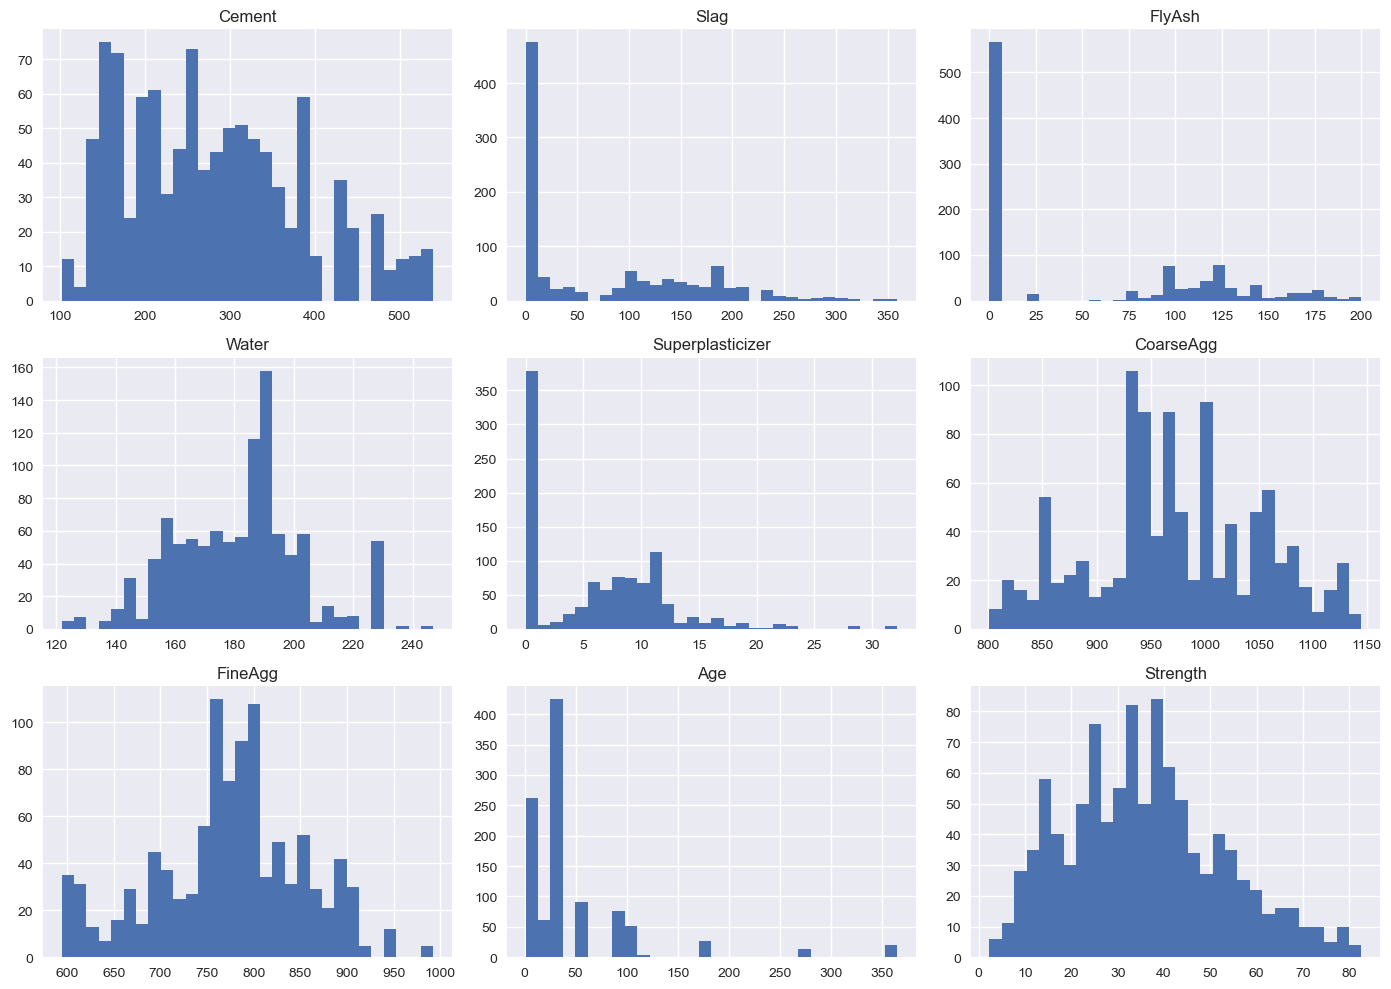

In [5]:
df.hist(figsize=(14,10), bins=30)
plt.tight_layout()
plt.show()

In [7]:
correlation_matrix = df.corr()

print(correlation_matrix)

                    Cement      Slag    FlyAsh     Water  Superplasticizer  \
Cement            1.000000 -0.275216 -0.397467 -0.081587          0.092386   
Slag             -0.275216  1.000000 -0.323580  0.107252          0.043270   
FlyAsh           -0.397467 -0.323580  1.000000 -0.256984          0.377503   
Water            -0.081587  0.107252 -0.256984  1.000000         -0.657533   
Superplasticizer  0.092386  0.043270  0.377503 -0.657533          1.000000   
CoarseAgg        -0.109349 -0.283999 -0.009961 -0.182294         -0.265999   
FineAgg          -0.222718 -0.281603  0.079108 -0.450661          0.222691   
Age               0.081946 -0.044246 -0.154371  0.277618         -0.192700   
Strength          0.497832  0.134829 -0.105755 -0.289633          0.366079   

                  CoarseAgg   FineAgg       Age  Strength  
Cement            -0.109349 -0.222718  0.081946  0.497832  
Slag              -0.283999 -0.281603 -0.044246  0.134829  
FlyAsh            -0.009961  0.079108 -

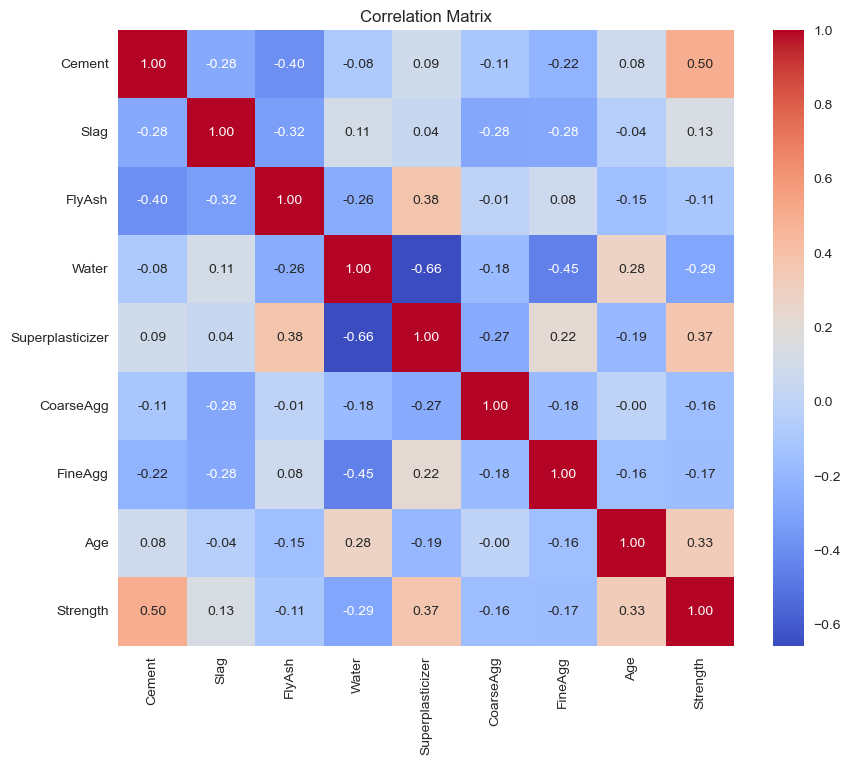

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            square=True)

plt.title("Correlation Matrix")
plt.show()